In [34]:
import os
import glob
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import ChromBERT utilities
import css_utility as crb

In [35]:
files = sorted(glob.glob("../processed/ltr_per_celltype/E*_ltr_pm1kb.csv"))
print("n_files:", len(files))  # should be 127

df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df_all.shape)

n_files: 127
(85363427, 11)


In [36]:
cell_ids = sorted({os.path.basename(f).split("_")[0] for f in files})
print(cell_ids[:10])
print(cell_ids[-10:])

['E001', 'E002', 'E003', 'E004', 'E005', 'E006', 'E007', 'E008', 'E009', 'E010']
['E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129']


In [46]:
df_all["eid_num"] = df_all["cell_id"].str.replace("E", "", regex=False).astype(int)
## Cancer samples are E114 to E129 (inclusive)
df_all["is_cancer"] = df_all["eid_num"].between(114, 129)

In [48]:
df_all

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer
0,chr1,20948,23075,MLT1K,254.0,+,2127,OOOOOOOOOOOO,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
1,chr1,29693,31848,MLT1A,741.0,+,2155,OOOOOOOOOOOO,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
2,chr1,29952,32131,MLT1A,741.0,+,2179,OOOOOOOOOOOO,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
3,chr1,33564,35921,MLT1J2,850.0,-,2357,OOOOOOOOOOOOO,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
4,chr1,37255,40464,MLT1E1A-int,3877.0,+,3209,OOOOOOOOOOOOOOOOO,17,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True
85363423,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True
85363424,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True
85363425,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True


In [50]:
### Calculate O state (quiscent state) ratio
df_all["O_ratio"] = df_all["state_seq_full_slice"].str.count("O") / df_all["n_bins"]

In [51]:
import pandas as pd

summary_per_cell = (
    df_all.groupby("cell_id")
    .agg(
        frac_quiescent=("O_ratio", lambda x: (x == 1).mean()),
        frac_engaged=("O_ratio", lambda x: (x == 0).mean()),
        is_cancer=("is_cancer", "first")
    )
    .reset_index()
)

# Add labels for cancer vs normal
summary_per_cell["group"] = summary_per_cell["is_cancer"].map({
    True: "Cancer",
    False: "Normal"
})

In [54]:
from scipy.stats import mannwhitneyu

normal_vals = summary_per_cell[summary_per_cell["group"]=="Normal"]["frac_engaged"]
cancer_vals = summary_per_cell[summary_per_cell["group"]=="Cancer"]["frac_engaged"]

stat, p = mannwhitneyu(normal_vals, cancer_vals)
print("p-value:", p)

p-value: 0.006654526495132435


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_92804/3368160820.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


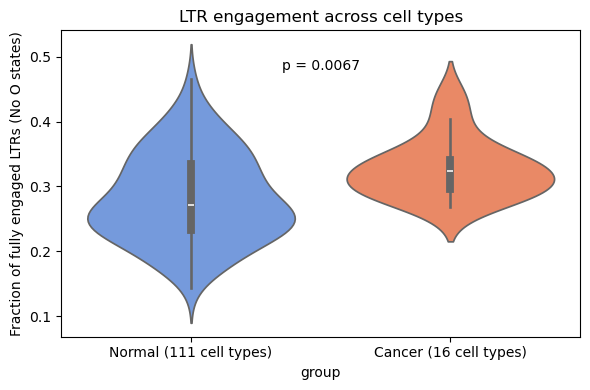

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt


palette = {
    "Normal": "cornflowerblue",
    "Cancer": "coral"
}

plt.figure(figsize=(6,4))

sns.violinplot(
    data=summary_per_cell,
    x="group",
    y="frac_engaged",  # O ratio is zero for fully engaged, so we can directly use it
    inner="box",
    palette=palette
)

plt.ylabel("Fraction of fully engaged LTRs (No O states)")
plt.title("LTR engagement across cell types")
plt.text(0.5, 0.48, "p = 0.0067", ha='center')
plt.xticks([0, 1], ["Normal (111 cell types)", "Cancer (16 cell types)"])
plt.tight_layout()
plt.show()

In [62]:
df_normal = df_all[~df_all["is_cancer"]].copy()
df_cancer = df_all[df_all["is_cancer"]].copy()

In [63]:
print(df_normal.shape)
print(df_cancer.shape)

(74650203, 14)
(10713224, 14)


<Axes: >

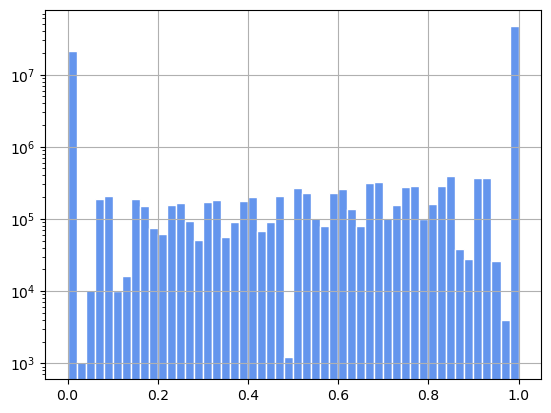

In [ ]:
df_normal["O_ratio"].hist(bins=50, log=True, color="cornflowerblue", edgecolor="white")

<Axes: >

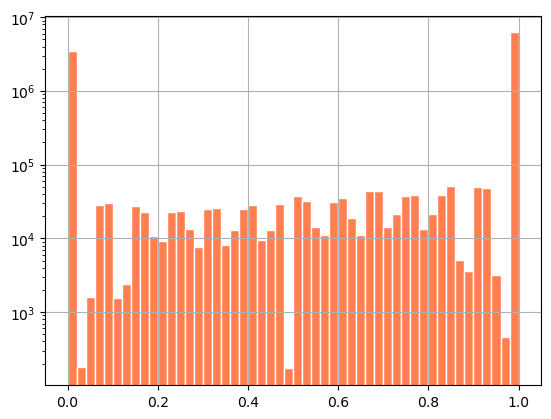

In [ ]:
df_cancer["O_ratio"].hist(bins=50, log=True, color="coral", edgecolor="white")

In [66]:
print((df_normal["O_ratio"] == 1).mean())
print((df_normal["O_ratio"] == 0).mean())

0.6202536247624135
0.28275435500155305


In [67]:
print((df_cancer["O_ratio"] == 1).mean())
print((df_cancer["O_ratio"] == 0).mean())

0.578746883291155
0.3275929822805908


### Fully engaged case (No O state)

In [68]:
from collections import Counter

def state_counts(seq):
    return Counter(seq)

df_normal_engaged = df_normal[df_normal["O_ratio"] == 0]
df_cancer_engaged = df_cancer[df_cancer["O_ratio"] == 0]

In [69]:
df_normal_engaged

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer,O_ratio
174,chr1,634542,636856,LTR39,3635.0,-,2314,NNNNNNNNNMMMM,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
175,chr1,635155,637458,LTR39,3635.0,-,2303,NNNNNNMMMMMMM,13,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
176,chr1,635578,637722,LTR39,3635.0,-,2144,NNNNMMMMMMMM,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
177,chr1,637233,639361,LTR33,473.0,+,2128,MMMNNNNNMMM,11,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
178,chr1,639608,641898,MLT1H,586.0,-,2290,MMMMMMMMMMMM,12,E001,E001_15_coreMarks_hg38lift_mnemonics.bed,1,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74650198,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0
74650199,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0
74650200,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0
74650201,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E113,E113_15_coreMarks_hg38lift_mnemonics.bed,113,False,0.0


In [70]:
df_cancer_engaged

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,source_bed,eid_num,is_cancer,O_ratio
74650377,chr1,634542,636856,LTR39,3635.0,-,2314,NNNNNNNNNNNNN,13,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650378,chr1,635155,637458,LTR39,3635.0,-,2303,NNNNNNNNNNNNN,13,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650379,chr1,635578,637722,LTR39,3635.0,-,2144,NNNNNNNNNNNN,12,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650380,chr1,637233,639361,LTR33,473.0,+,2128,NNNNNNNNNNN,11,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
74650381,chr1,639608,641898,MLT1H,586.0,-,2290,NNNNNNNNNNNN,12,E114,E114_15_coreMarks_hg38lift_mnemonics.bed,114,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363423,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363424,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0
85363425,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,E129,E129_15_coreMarks_hg38lift_mnemonics.bed,129,True,0.0


In [41]:
from collections import Counter

all_seq_normal_engaged = "".join(df_normal_engaged["state_seq_full_slice"].dropna())
all_seq_cancer_engaged = "".join(df_cancer_engaged["state_seq_full_slice"].dropna())

state_counts_normal_engaged = Counter(all_seq_normal_engaged)
state_counts_cancer_engaged = Counter(all_seq_cancer_engaged)

In [71]:
total_normal_engaged = sum(state_counts_normal_engaged.values())
total_cancer_engaged = sum(state_counts_cancer_engaged.values())

state_freq_normal_engaged = {k: v / total_normal_engaged for k, v in state_counts_normal_engaged.items()}
state_freq_cancer_engaged = {k: v / total_cancer_engaged for k, v in state_counts_cancer_engaged.items()}

In [72]:
import matplotlib.pyplot as plt

# A~O order
state_order = list("ABCDEFGHIJKLMNO")

# fill 0 for missing states
state_freq_ordered_normal_engaged = {k: state_freq_normal_engaged.get(k, 0) for k in state_order}
state_freq_ordered_cancer_engaged = {k: state_freq_cancer_engaged.get(k, 0) for k in state_order}

# color mapping based on ChromBERT's state_col_dict_num
colors = [crb.state_col_dict_num[k] for k in state_order]

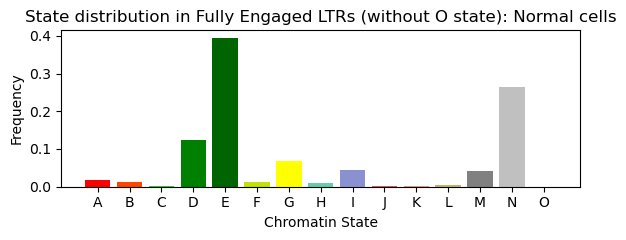

In [83]:
# plot normal
plt.figure(figsize=(6,2.5))
plt.bar(state_order, state_freq_ordered_normal_engaged.values(), color=colors)

plt.xlabel("Chromatin State")
plt.ylabel("Frequency")
plt.title("State distribution in Fully Engaged LTRs (without O state): Normal cells")

plt.tight_layout()
plt.show()

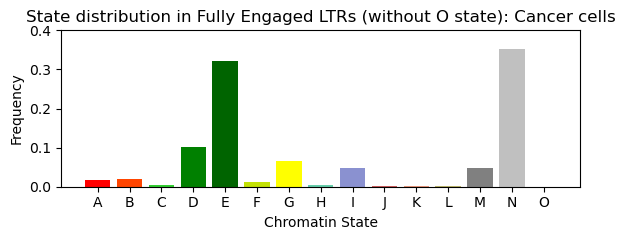

In [84]:
# plot cancer
plt.figure(figsize=(6,2.5))
plt.bar(state_order, state_freq_ordered_cancer_engaged.values(), color=colors)

plt.xlabel("Chromatin State")
plt.ylabel("Frequency")
plt.title("State distribution in Fully Engaged LTRs (without O state): Cancer cells")
plt.ylim(0,0.4)
plt.tight_layout()
plt.show()

In [86]:
from collections import Counter

def get_state_freq(df):
    all_seq = "".join(df["state_seq_full_slice"].dropna())
    counts = Counter(all_seq)
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

normal_freq = get_state_freq(df_normal_engaged)
cancer_freq = get_state_freq(df_cancer_engaged)

diff = {
    k: cancer_freq.get(k, 0) - normal_freq.get(k, 0)
    for k in state_order
}

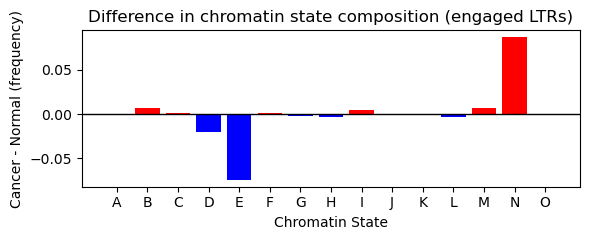

In [100]:
plt.figure(figsize=(6,2.5))

colors = ["red" if v > 0 else "blue" for v in diff.values()]

plt.bar(state_order, diff.values(), color=colors)
# plt.bar(state_order, diff.values(), color="silver")
plt.axhline(0, color='black', linewidth=1)

plt.xlabel("Chromatin State")
plt.ylabel("Cancer - Normal (frequency)")
plt.title("Difference in chromatin state composition (engaged LTRs)")

plt.tight_layout()
plt.show()

**Fully engaged LTRs exhibit similar chromatin state compositions between normal and cancer cells.**

In [102]:
def state_fraction_per_cell(df, state):
    return (
        df.groupby("cell_id")["state_seq_full_slice"]
        .apply(lambda x: sum(s.count(state) for s in x) / sum(len(s) for s in x))
    )

In [103]:
state = "E"

frac_per_cell = state_fraction_per_cell(df_all[df_all["O_ratio"] == 0], state)

summary = frac_per_cell.reset_index(name="frac")
summary["is_cancer"] = summary["cell_id"].map(
    df_all.groupby("cell_id")["is_cancer"].first()
)

from scipy.stats import mannwhitneyu

normal = summary[summary["is_cancer"] == False]["frac"]
cancer = summary[summary["is_cancer"] == True]["frac"]

stat, p = mannwhitneyu(normal, cancer)
print(p)

0.005451895280150077


In [104]:
state = "N"

frac_per_cell = state_fraction_per_cell(df_all[df_all["O_ratio"] == 0], state)

summary = frac_per_cell.reset_index(name="frac")
summary["is_cancer"] = summary["cell_id"].map(
    df_all.groupby("cell_id")["is_cancer"].first()
)

from scipy.stats import mannwhitneyu

normal = summary[summary["is_cancer"] == False]["frac"]
cancer = summary[summary["is_cancer"] == True]["frac"]

stat, p = mannwhitneyu(normal, cancer)
print(p)

7.619843621221474e-05


# Predict normal vs cancer from LTR chromatin-state features

## 1. Add the first baseline features

In [ ]:
# Step A: Add transition count

def count_transitions(seq):
    return sum(1 for i in range(len(seq) - 1) if seq[i] != seq[i + 1])

In [107]:
df_all["n_transitions"] = df_all["state_seq_full_slice"].apply(count_transitions)
df_all["transition_density"] = df_all["n_transitions"] / df_all["n_bins"]

In [108]:
# Step B: Add number of unique states
df_all["n_unique_states"] = df_all["state_seq_full_slice"].apply(lambda s: len(set(s)))

In [109]:
# Step C: Add entorpy
import math
from collections import Counter

def seq_entropy(seq):
    counts = Counter(seq)
    total = len(seq)
    probs = [c / total for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

df_all["entropy"] = df_all["state_seq_full_slice"].apply(seq_entropy)

In [110]:
# Step D: Add per-state fractions
state_order = list("ABCDEFGHIJKLMNO")

for state in state_order:
    df_all[f"frac_{state}"] = df_all["state_seq_full_slice"].apply(lambda s: s.count(state) / len(s))

In [112]:
df_all.head()

,chrom,start,end,name,score,strand,length,state_seq_full_slice,n_bins,cell_id,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,chr1,20948,23075,MLT1K,254.0,+,2127,OOOOOOOOOOOO,12,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,chr1,29693,31848,MLT1A,741.0,+,2155,OOOOOOOOOOOO,12,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,chr1,29952,32131,MLT1A,741.0,+,2179,OOOOOOOOOOOO,12,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,chr1,33564,35921,MLT1J2,850.0,-,2357,OOOOOOOOOOOOO,13,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,chr1,37255,40464,MLT1E1A-int,3877.0,+,3209,OOOOOOOOOOOOOOOOO,17,E001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [113]:
# Save a feature table with all the calculated features for downstream analysis

feature_cols = [
    "cell_id", "is_cancer", "chrom", "start", "end", "name",
    "length", "n_bins", "O_ratio",
    "n_transitions", "transition_density", "n_unique_states", "entropy"
] + [f"frac_{s}" for s in state_order]

df_features = df_all[feature_cols].copy()
df_features.to_csv("../processed/ltr_feature_table.csv", index=False)

In [114]:
df_features.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [116]:
df_features.columns.unique()

Index(['cell_id', 'is_cancer', 'chrom', 'start', 'end', 'name', 'length',
       'n_bins', 'O_ratio', 'n_transitions', 'transition_density',
       'n_unique_states', 'entropy', 'frac_A', 'frac_B', 'frac_C', 'frac_D',
       'frac_E', 'frac_F', 'frac_G', 'frac_H', 'frac_I', 'frac_J', 'frac_K',
       'frac_L', 'frac_M', 'frac_N', 'frac_O'],
      dtype='object')

In [115]:
len(df_features)

85363427

In [117]:
import pandas as pd

df = pd.read_csv("../processed/ltr_feature_table.csv")
print(df.shape)

(85363427, 28)


In [118]:
exclude_cols = [
    "cell_id", "chrom", "start", "end", "name", "is_cancer"
]

feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols]
y = df["is_cancer"]

In [119]:
X = X.fillna(0)

In [120]:
# Train/test split (quick version)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [121]:
# Standardize + logistic regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [122]:
# Evaluate (key step)

from sklearn.metrics import roc_auc_score, accuracy_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.874498658266192
ROC AUC: 0.5388585984232683


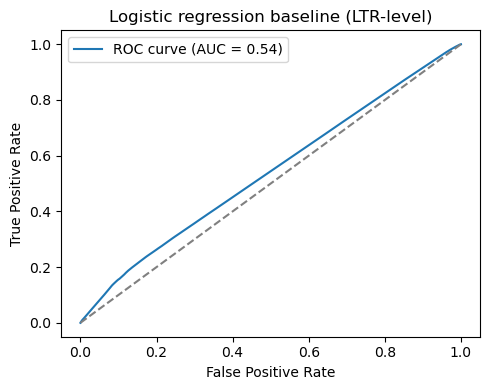

In [140]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic regression baseline (LTR-level)")
plt.legend()

plt.tight_layout()
plt.show()

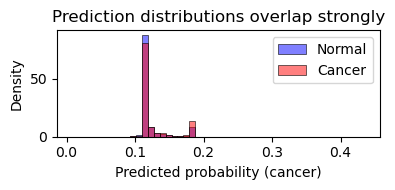

In [128]:
import seaborn as sns

plt.figure(figsize=(4,2))

sns.histplot(y_prob[y_test==0], color="blue", label="Normal", stat="density", bins=50, alpha=0.5)
sns.histplot(y_prob[y_test==1], color="red", label="Cancer", stat="density", bins=50, alpha=0.5)

plt.xlabel("Predicted probability (cancer)")
plt.title("Prediction distributions overlap strongly")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Check feature importance

import numpy as np

coef = model.named_steps["clf"].coef_[0]

importance = pd.Series(coef, index=feature_cols)
importance = importance.sort_values(key=lambda x: abs(x), ascending=False)

print(importance.head(20))

frac_N                0.097747
frac_L               -0.070724
frac_B                0.066295
frac_E               -0.046058
frac_O               -0.034001
O_ratio              -0.034001
frac_M                0.033752
frac_H               -0.026914
transition_density   -0.022317
frac_A               -0.021350
entropy               0.021311
n_transitions        -0.017852
frac_C                0.017607
frac_G                0.017064
frac_D               -0.016533
frac_J               -0.016060
frac_F                0.010844
frac_I                0.007657
n_unique_states      -0.007022
frac_K               -0.003174
dtype: float64


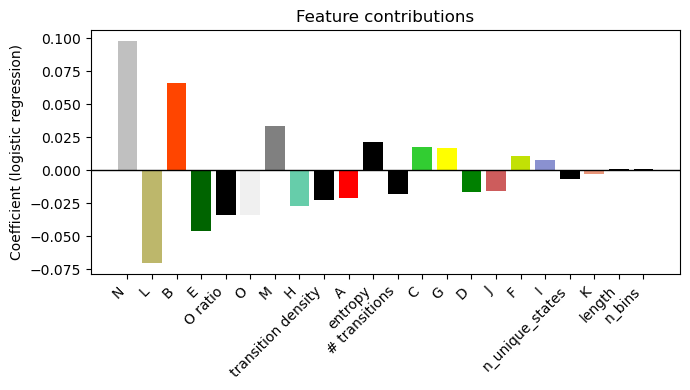

In [147]:
state_cols = [f"frac_{s}" for s in list("ABCDEFGHIJKLMNO")]
state_importance = importance[state_cols]
other_cols = [c for c in importance.index if c not in state_cols]
other_importance = importance[other_cols]
combined = pd.concat([state_importance, other_importance])
combined = combined.sort_values(key=lambda x: abs(x), ascending=False)
colors = []

for col in combined.index:
    if col.startswith("frac_"):
        state = col.split("_")[1]
        colors.append(crb.state_col_dict_num[state])
    else:
        colors.append("black")  # black for non-state features

import matplotlib.pyplot as plt

def pretty_name(col):
    if col.startswith("frac_"):
        return col.split("_")[1]
    elif col == "O_ratio":
        return "O ratio"
    elif col == "n_transitions":
        return "# transitions"
    elif col == "transition_density":
        return "transition density"
    else:
        return col

labels = [pretty_name(c) for c in combined.index]

plt.figure(figsize=(7,4))

plt.bar(range(len(combined.index)), combined.values, color=colors)

plt.axhline(0, color="black", linewidth=1)

plt.xticks(
    ticks=range(len(combined.index)),
    labels=labels,
    rotation=45,
    ha="right"
)

plt.ylabel("Coefficient (logistic regression)")
plt.title("Feature contributions")

plt.tight_layout()
plt.show()



#### Cancer effect is subtle and distributed across LTRs, not strong at individual LTR level

- No single LTR strongly signals cancer
- But aggregate statistics shift

Simple statistical features show **limited predictive power** at the LTR level (ROC AUC ≈ 0.54),
suggesting that cancer-related signals are subtle and distributed rather than localized to individual elements.


### "weak sequence-awareness” without deep models

#### 1. Bigram (2-mer) features

If a sequence is: `EEEEDDG`

then the bigrams are: `EE, EE, EE, ED, DD, DG`

This keeps local context.

In [165]:
#### save the file for sequence analysis

df_seq = df_all[[
    "cell_id", "chrom", "start", "end", "name",
    "state_seq_full_slice", "is_cancer"
]]

df_seq.to_csv("../processed/ltr_sequences.csv", index=False)

In [186]:
# Start with a manageable subset just to make sure the code works.
# df_small = df_seq.sample(200000, random_state=42).copy()
# print(df_small.shape)
df_features_small = df_features.sample(200000, random_state=42).copy()
df_seq_small = df_seq.loc[df_features_small.index].copy()

In [188]:
exclude_cols = [
    "cell_id", "chrom", "start", "end", "name", "is_cancer"
]

base_feature_cols = [c for c in df_features_small.columns if c not in exclude_cols]

X_base = df_features_small[base_feature_cols].fillna(0)
y = df_features_small["is_cancer"]

In [191]:
from collections import Counter

def bigram_freq_dict(seq, bigram_list):
    if pd.isna(seq) or len(seq) < 2:
        return {bg: 0.0 for bg in bigram_list}
    
    bigrams = [seq[i:i+2] for i in range(len(seq) - 1)]
    counts = Counter(bigrams)
    total = len(bigrams)
    
    return {bg: counts.get(bg, 0) / total for bg in bigram_list}

In [193]:
state_order = list("ABCDEFGHIJKLMNO")
bigram_list = [a + b for a in state_order for b in state_order]
print(len(bigram_list))
print(bigram_list[:10])

225
['AA', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ']


In [194]:
example_seq = df_seq_small["state_seq_full_slice"].iloc[0]
print(example_seq)

test_bigram = bigram_freq_dict(example_seq, bigram_list)
list(test_bigram.items())[:10]

OOOOOOOOOOOOO


[('AA', 0.0),
 ('AB', 0.0),
 ('AC', 0.0),
 ('AD', 0.0),
 ('AE', 0.0),
 ('AF', 0.0),
 ('AG', 0.0),
 ('AH', 0.0),
 ('AI', 0.0),
 ('AJ', 0.0)]

In [195]:
bigram_df = df_seq_small["state_seq_full_slice"].apply(
    lambda s: pd.Series(bigram_freq_dict(s, bigram_list))
)
bigram_df.columns = [f"bg_{c}" for c in bigram_df.columns]

In [197]:
print(bigram_df.shape)
bigram_df.tail()

(200000, 225)


,bg_AA,bg_AB,bg_AC,bg_AD,bg_AE,bg_AF,bg_AG,bg_AH,bg_AI,bg_AJ,...,bg_OF,bg_OG,bg_OH,bg_OI,bg_OJ,bg_OK,bg_OL,bg_OM,bg_ON,bg_OO
22659065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10438266,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
42190458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2562101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
28853881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [198]:
X_bigram = pd.concat(
    [X_base.reset_index(drop=True), bigram_df.reset_index(drop=True)],
    axis=1
)
print(X_bigram.shape)

(200000, 247)


In [199]:
# Then split both matrices using the same labels:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

Xbg_train, Xbg_test, _, _ = train_test_split(
    X_bigram, y, test_size=0.2, random_state=42, stratify=y
)

In [200]:
# Run baseline logistic regression:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])

base_model.fit(Xb_train, y_train)

y_prob_base = base_model.predict_proba(Xb_test)[:, 1]
y_pred_base = base_model.predict(Xb_test)

print("BASELINE")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("ROC AUC:", roc_auc_score(y_test, y_prob_base))

BASELINE
Accuracy: 0.8744
ROC AUC: 0.5402210941688496


In [202]:
# Then run the biagram model:
bigram_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])

bigram_model.fit(Xbg_train, y_train)

y_prob_bigram = bigram_model.predict_proba(Xbg_test)[:, 1]
y_pred_bigram = bigram_model.predict(Xbg_test)

print("BIGRAM MODEL")
print("Accuracy:", accuracy_score(y_test, y_pred_bigram))
print("ROC AUC:", roc_auc_score(y_test, y_prob_bigram))

BIGRAM MODEL
Accuracy: 0.874325
ROC AUC: 0.5419503224640663


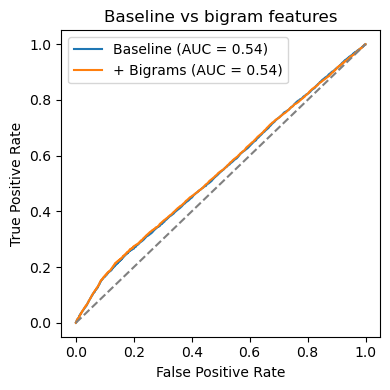

In [205]:
# Finally, compare ROC curves:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_bigram, tpr_bigram, _ = roc_curve(y_test, y_prob_bigram)

auc_base = auc(fpr_base, tpr_base)
auc_bigram = auc(fpr_bigram, tpr_bigram)

plt.figure(figsize=(4,4))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {auc_base:.2f})")
plt.plot(fpr_bigram, tpr_bigram, label=f"+ Bigrams (AUC = {auc_bigram:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline vs bigram features")
plt.legend()
plt.tight_layout()
plt.show()

In [204]:
print(X_bigram.shape)

(200000, 247)
